# Revisi - Tahap 5: Visualisasi Perjalanan Data (raw -> train-ready)

Satu notebook utuh: gimana data berubah dari mentah sampai siap latih. Semua angka
**dihitung langsung dari file** di `data/` (bukan ketik manual).

Alur pipa:

```
RAW (merged_dataset)                      soal mentah, hasil scrape+ekstrak PDF
  -> CLEAN per-split (data/Final/*)       rule-filter + LLM-validity + dedup/decontam
  -> CoT CANDIDATES (data/cot/*)          guru bikin N solusi/soal (DeepSeek/ERNIE/Qwen-Math)
  -> CORRECT (rejection sampling)         simpan hanya solusi yg boxed == gold
  -> CHATML (data/sft/full_data/*)        format ChatML, 1 solusi/soal
  -> TRAIN-READY (data/sft/train/*)       cot.jsonl & nocot.jsonl (gabung + dedup)
TEST gold (held-out) 300 -> test_clean    dibersihkan utk eval yg sah
```

## Proses tiap tahap (kenapa hasilnya begitu)

Tiap penurunan jumlah di grafik = satu langkah penyaringan nyata di kode. Ringkasnya:

| tahap | modul | proses | efek ke jumlah |
|---|---|---|---|
| scrape + ekstrak | `scraping_ver2/*`, `preprop/extract*` | scrape OSN + ekstrak PDF (2 metode) jadi `{soal,cara,jawaban}` | sumber mentah, masih banyak noise/OCR |
| merge + dedup | `preprop/merge_and_dedup` | gabung sumber, dedup by `soal`, simpan versi TERLENGKAP (punya jawaban > punya cara > cara terpanjang) | soal kembar antar-sumber dibuang |
| rule filter | `preprop/filter_rules` | buang soal langgar aturan (kosong / format rusak) | turun |
| LLM validity | `preprop/filter_validity` (Qwen2.5-7B) | tanya model: soal well-formed & **bisa dijawab dari teks saja**? | soal ill-formed / butuh data luar dibuang |
| embed dedup + decontam | `preprop/dedup` | cosine **>0.92** -> dedup; cosine **>0.90 vs benchmark** -> decontam | near-duplikat + bocoran benchmark dibuang |
| split held-out | `preprop/split_final` (seeded) | carve **300/dataset** jadi TEST, sisanya TRAIN; karena dedup duluan, test tak punya kembaran di train | TEST dipisah dari TRAIN |
| CoT gen (guru) | `cot_synthesis/generate` (DeepSeek-R1) | tiap soal disuruh guru bikin **N solusi** (temp 0.7, top-p 0.95), dipaksa ada `\boxed{}` | **NAIK** (N x soal), bukan turun |
| rejection sampling | `cot_synthesis/filter_solutions` | (1) wajib `\boxed{}` brace-balanced (komplit); (2) **LLM-judge**: boxed guru == gold? | solusi tak-komplit / salah dibuang -> **ATRISI TERBESAR** |
| to chatml | `cot_synthesis/to_chatml` | dari solusi benar yg SAMA -> `cot` (penalaran+boxed) & `nocot` (boxed saja) | format; 1 soal bisa banyak solusi |
| build train | `training/build_train` | gabung guru PEMENANG (DeepSeek), turunkan `nocot` dari baris yg sama, **decontam vs test** | bocoran ke test dibuang dari train |
| clean test | `preprop/clean_testset` | buang gold rusak / butuh data luar / `cara`!=gold | test 300 -> 161 / 94 |

**Kenapa hasil akhir kecil & numglue lebih rontok dari easy:** dua saringan ketat berturut
(LLM-validity lalu LLM-judge rejection). numglue banyak soal butuh konteks luar -> lebih sering
ditolak validity & guru lebih sering salah -> retensi numglue (40%) < easy (62%). Itu disengaja:
lebih baik train kecil-tapi-bersih daripada besar-tapi-bising.

In [1]:
import os, sys
p = os.getcwd()
while not os.path.isdir(os.path.join(p, 'src')) and os.path.dirname(p) != p:
    p = os.path.dirname(p)
os.chdir(p); sys.path.insert(0, p)
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
from src.preprop.inspect_data import _read_jsonl, _soal_of_chatml, _assistant_of_chatml, answer_shape
from src.eval.answer_check import normalize_str
print('repo root:', p)

repo root: D:\Main Storage\Vscode\FP_NLP\FP_NLP


In [2]:
# ---- peta file tiap tahap (sumber kebenaran) ----
RAW   = 'data/merged_dataset.jsonl'
CLEAN = {'numglue':'data/Final/numglue_clean.jsonl',
         'easy':'data/Final/easy_clean.jsonl',
         'aimo_hard':'data/Final/aimo_hard_clean.jsonl'}
CAND  = {'numglue':'data/cot/num_glue/cot_numglue_DeepSeek-R1-Distill-Qwen-7B.jsonl',
         'easy':'data/cot/vllm_un/cot_easy_DeepSeek-R1-Distill-Qwen-7B.jsonl'}
CORR  = {'numglue':'data/cot/num_glue/correct_numglue_DeepSeek-R1-Distill-Qwen-7B.jsonl',
         'easy':'data/cot/vllm_un/correct_easy_DeepSeek-R1-Distill-Qwen-7B.jsonl'}
TRAIN_COT, TRAIN_NOCOT = 'data/sft/train/cot.jsonl', 'data/sft/train/nocot.jsonl'
TEST = {'numglue':('data/sft/test/numglue_test.jsonl','data/sft/test_clean/numglue_test.jsonl'),
        'easy':('data/sft/test/easy_test.jsonl','data/sft/test_clean/easy_test.jsonl')}

def gold_soals(pth): return [normalize_str(r.get('soal','') or '') for r in _read_jsonl(pth)]
def uniq_gold(pth):  return len({s for s in gold_soals(pth) if s})
def uniq_ids(pth):   return len({r.get('id') for r in _read_jsonl(pth) if r.get('id') is not None})
def uniq_chatml(pth):return len({normalize_str(_soal_of_chatml(r)) for r in _read_jsonl(pth)})
def nrows(pth):      return sum(1 for _ in _read_jsonl(pth))
print('helpers siap')

helpers siap


## 1. Funnel level-SOAL: berapa banyak *problem* selamat tiap tahap

Dihitung unik per soal (bukan baris), jadi adil dibanding tahap yg punya banyak kandidat/soal.
Cakupan funnel = numglue + easy (rantai lengkap & bisa ditelusuri).

**Proses tiap loncatan:** RAW->CLEAN = rule + LLM-validity + embed dedup/decontam.
CLEAN->lolos = guru bikin N solusi lalu rejection sampling (wajib `\boxed`, judge boxed==gold).
lolos->train-ready = format chatml + decontam vs test (`build_train`).

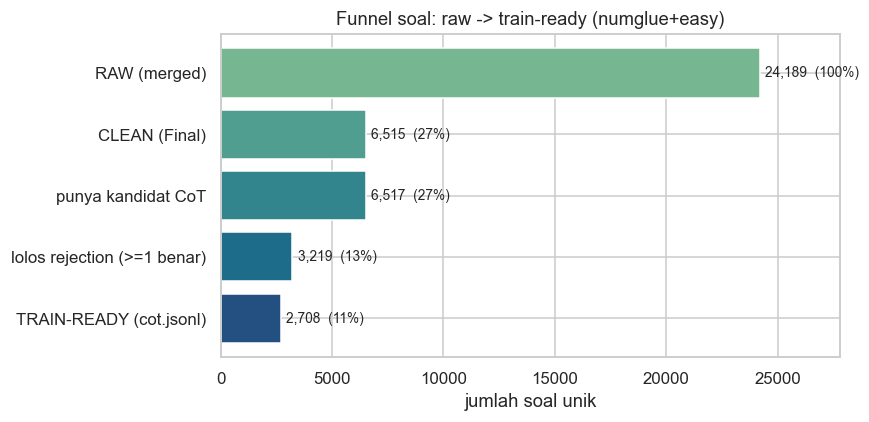

,soal_unik
RAW (merged),24189
CLEAN (Final),6515
punya kandidat CoT,6517
lolos rejection (>=1 benar),3219
TRAIN-READY (cot.jsonl),2708


In [3]:
stages = {}
stages['RAW (merged)'] = uniq_gold(RAW)
stages['CLEAN (Final)'] = uniq_gold(CLEAN['numglue']) + uniq_gold(CLEAN['easy'])
stages['punya kandidat CoT'] = uniq_ids(CAND['numglue']) + uniq_ids(CAND['easy'])
stages['lolos rejection (>=1 benar)'] = uniq_ids(CORR['numglue']) + uniq_ids(CORR['easy'])
stages['TRAIN-READY (cot.jsonl)'] = uniq_chatml(TRAIN_COT)

s = pd.Series(stages)
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(range(len(s)), s.values, color=sns.color_palette("crest", len(s)))
ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index); ax.invert_yaxis()
base = s.iloc[0]
for i,(k,v) in enumerate(s.items()):
    ax.text(v+base*0.01, i, f'{v:,}  ({v/base:.0%})', va='center', fontsize=9)
ax.set_xlabel('jumlah soal unik'); ax.set_title('Funnel soal: raw -> train-ready (numglue+easy)')
ax.set_xlim(0, base*1.15); plt.tight_layout(); plt.show()
display(s.to_frame('soal_unik'))

## 2. Atrisi per-dataset (numglue vs easy)

Di tahap mana tiap dataset paling banyak rontok.

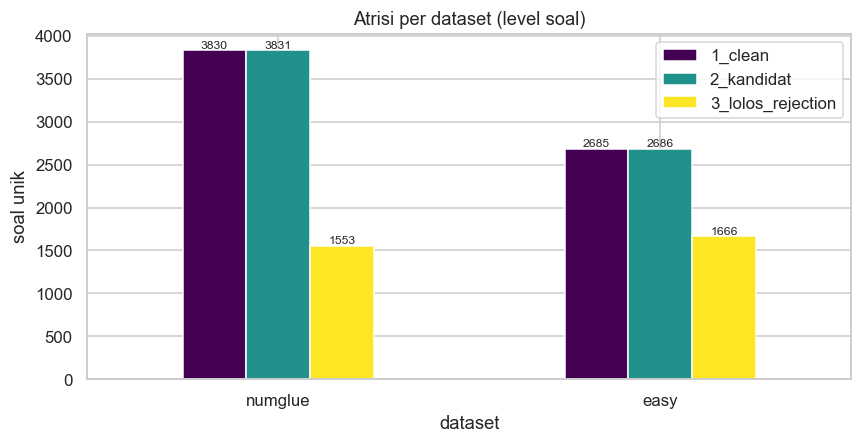

,1_clean,2_kandidat,3_lolos_rejection,retensi_clean->lolos
dataset,,,,
numglue,3830,3831,1553,0.405
easy,2685,2686,1666,0.620


In [4]:
rows = []
for ds in ['numglue','easy']:
    rows.append({'dataset':ds,'1_clean':uniq_gold(CLEAN[ds]),
                 '2_kandidat':uniq_ids(CAND[ds]),'3_lolos_rejection':uniq_ids(CORR[ds])})
att = pd.DataFrame(rows).set_index('dataset')
ax = att.plot(kind='bar', figsize=(8,4.2), colormap='viridis', rot=0)
ax.set_ylabel('soal unik'); ax.set_title('Atrisi per dataset (level soal)')
for cont in ax.containers: ax.bar_label(cont, fontsize=8)
plt.tight_layout(); plt.show()
att['retensi_clean->lolos'] = (att['3_lolos_rejection']/att['1_clean']).round(3)
display(att)

## 3. Hasil rejection sampling per GURU (kenapa DeepSeek dipilih)

Kandidat (baris) -> yang benar (boxed == gold). Yield rendah = guru sering salah / tak ber-\boxed.
Ini alasan objektif milih teacher.

**Proses:** `filter_solutions` cek tiap kandidat: ada `\boxed` brace-balanced? lalu LLM-judge
banding boxed guru vs gold. Yield = lolos / total kandidat. Guru kecil (ERNIE-0.3B) jarang benar
-> yield anjlok -> dibuang dari pemenang.

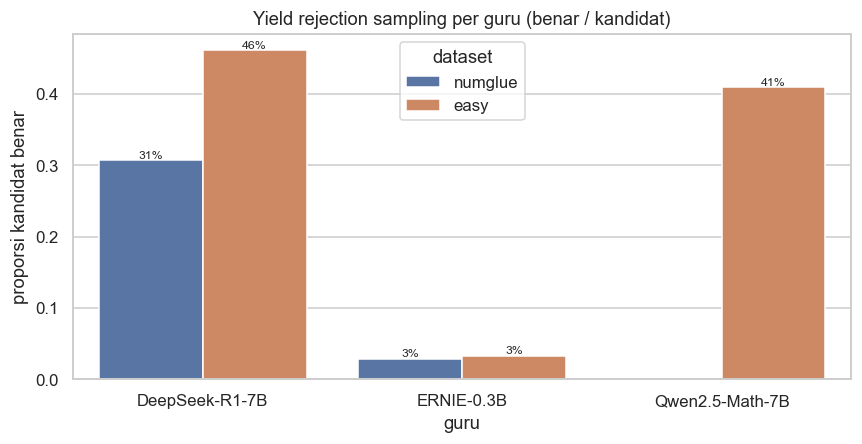

,dataset,guru,kandidat,benar,yield
0,numglue,DeepSeek-R1-7B,15324,4708,0.307
1,numglue,ERNIE-0.3B,15324,448,0.029
2,easy,DeepSeek-R1-7B,10744,4958,0.461
3,easy,ERNIE-0.3B,10744,356,0.033
4,easy,Qwen2.5-Math-7B,10744,4391,0.409


In [5]:
TEACHERS = {
 ('numglue','DeepSeek-R1-7B'): ('data/cot/num_glue/cot_numglue_DeepSeek-R1-Distill-Qwen-7B.jsonl',
                                'data/cot/num_glue/correct_numglue_DeepSeek-R1-Distill-Qwen-7B.jsonl'),
 ('numglue','ERNIE-0.3B'):     ('data/cot/num_glue/cot_numglue_ERNIE-4.5-0.3B-PT.jsonl',
                                'data/cot/num_glue/correct_numglue_ERNIE-4.5-0.3B-PT.jsonl'),
 ('easy','DeepSeek-R1-7B'):    ('data/cot/vllm_un/cot_easy_DeepSeek-R1-Distill-Qwen-7B.jsonl',
                                'data/cot/vllm_un/correct_easy_DeepSeek-R1-Distill-Qwen-7B.jsonl'),
 ('easy','ERNIE-0.3B'):        ('data/cot/vllm_un/cot_easy_ERNIE-4.5-0.3B-PT.jsonl',
                                'data/cot/vllm_un/correct_easy_ERNIE-4.5-0.3B-PT.jsonl'),
 ('easy','Qwen2.5-Math-7B'):   ('data/cot/vllm_un/cot_easy_Qwen2.5-Math-7B-Instruct.jsonl',
                                'data/cot/vllm_un/correct_easy_Qwen2.5-Math-7B-Instruct.jsonl'),
}
yr = []
for (ds,teacher),(cand,corr) in TEACHERS.items():
    nc, ng = nrows(cand), nrows(corr)
    yr.append({'dataset':ds,'guru':teacher,'kandidat':nc,'benar':ng,'yield':round(ng/nc,3)})
ydf = pd.DataFrame(yr)
fig, ax = plt.subplots(figsize=(8,4.2))
sns.barplot(data=ydf, x='guru', y='yield', hue='dataset', ax=ax)
ax.set_title('Yield rejection sampling per guru (benar / kandidat)')
ax.set_ylabel('proporsi kandidat benar')
for cont in ax.containers: ax.bar_label(cont, fmt='%.0f%%', labels=[f'{v*100:.0f}%' for v in cont.datavalues], fontsize=8)
plt.tight_layout(); plt.show()
display(ydf)

## 4. Sebaran panjang soal: raw vs clean vs train

Lihat efek pembersihan ke distribusi panjang (potong yg ekstrem pendek/panjang).

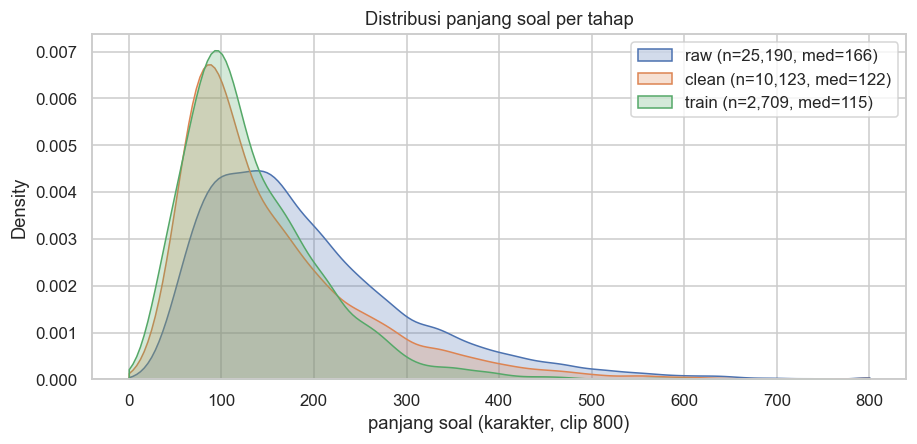

In [6]:
def soal_lens_gold(pth): return [len(r.get('soal','') or '') for r in _read_jsonl(pth)]
def soal_lens_chatml(pth): return [len(_soal_of_chatml(r)) for r in _read_jsonl(pth)]
L_raw = soal_lens_gold(RAW)
L_clean = sum((soal_lens_gold(CLEAN[d]) for d in CLEAN), [])
L_train = soal_lens_chatml(TRAIN_COT)
fig, ax = plt.subplots(figsize=(8.5,4.2))
for lab, data, col in [('raw',L_raw,'#bbbbbb'),('clean',L_clean,'#2a9d8f'),('train',L_train,'#e76f51')]:
    sns.kdeplot(np.clip(data,0,800), ax=ax, label=f'{lab} (n={len(data):,}, med={int(np.median(data))})',
                fill=True, alpha=0.25, clip=(0,800))
ax.set_xlabel('panjang soal (karakter, clip 800)'); ax.set_title('Distribusi panjang soal per tahap')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Bentuk jawaban gold (numeric / fraction / expr / text / empty)

`text`/`empty` = susah di-autograde. Lihat komposisi tiap split clean.

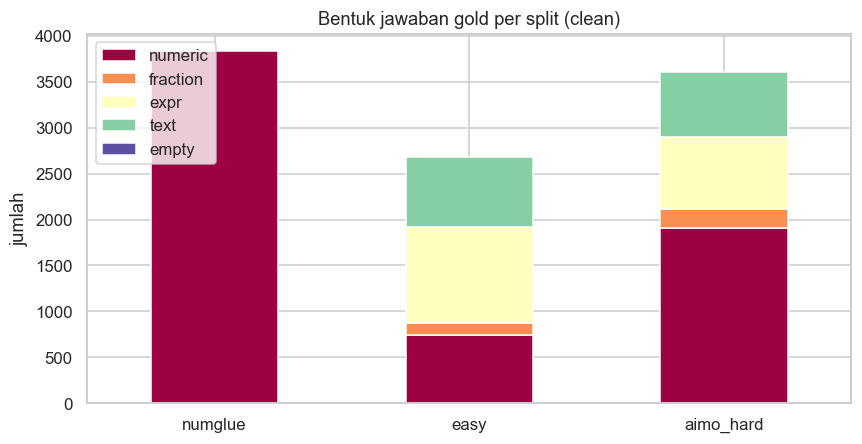

,numeric,fraction,expr,text,empty
numglue,3831,0,0,0,0
easy,748,128,1044,766,0
aimo_hard,1913,202,789,702,0


In [7]:
shape_rows = {}
for ds in ['numglue','easy','aimo_hard']:
    cnt = Counter(answer_shape(str(r.get('jawaban','') or '')) for r in _read_jsonl(CLEAN[ds]))
    shape_rows[ds] = cnt
order = ['numeric','fraction','expr','text','empty']
sh = pd.DataFrame(shape_rows).reindex(order).fillna(0).T
ax = sh.plot(kind='bar', stacked=True, figsize=(8,4.2), colormap='Spectral', rot=0)
ax.set_ylabel('jumlah'); ax.set_title('Bentuk jawaban gold per split (clean)')
plt.tight_layout(); plt.show()
display(sh.astype(int))

## 6. CoT vs non-CoT: panjang jawaban assistant (inti eksperimen)

cot = penalaran penuh + \boxed; nocot = \boxed saja. Harusnya cot jauh lebih panjang.

**Proses:** `to_chatml`/`build_train` bikin dua arm dari solusi benar yg SAMA -> nocot = buang
penalaran, sisakan `\boxed{pred}`. Base + hyperparam dibikin identik, cuma data ini yg beda ->
mengisolasi efek CoT (inti pertanyaan riset). Gap panjang di grafik = bukti dua arm beneran beda.

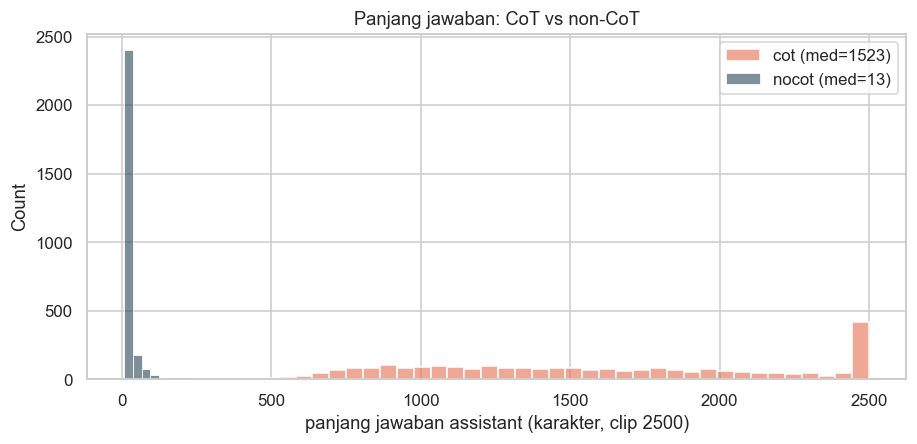

In [8]:
cot_len = [len(_assistant_of_chatml(r)) for r in _read_jsonl(TRAIN_COT)]
noc_len = [len(_assistant_of_chatml(r)) for r in _read_jsonl(TRAIN_NOCOT)]
fig, ax = plt.subplots(figsize=(8.5,4.2))
sns.histplot(np.clip(cot_len,0,2500), bins=40, color='#e76f51', label=f'cot (med={int(np.median(cot_len))})', alpha=0.6, ax=ax)
sns.histplot(np.clip(noc_len,0,2500), bins=40, color='#264653', label=f'nocot (med={int(np.median(noc_len))})', alpha=0.6, ax=ax)
ax.set_xlabel('panjang jawaban assistant (karakter, clip 2500)')
ax.set_title('Panjang jawaban: CoT vs non-CoT'); ax.legend(); plt.tight_layout(); plt.show()

## 7. Efek pembersihan test set (untuk eval yg sah)

Test gold dibersihkan (buang label rusak / butuh data luar). Sisa = yg dipakai skor pass@k baru.

**Proses:** `clean_testset` jatuhkan baris berdasar prioritas: jawaban kosong -> soal rusak ->
mojibake -> butuh konteks luar -> `cara` != gold (pakai grader yg sama dgn eval). numglue lebih
banyak terbuang krn banyak soal numglue butuh data luar (cocok temuan audit kualitas).

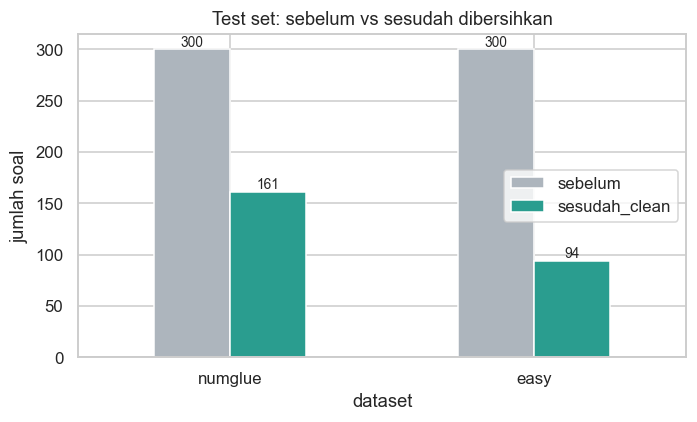

,sebelum,sesudah_clean,terbuang_%
dataset,,,
numglue,300,161,46.3
easy,300,94,68.7


In [9]:
tc = []
for ds,(before,after) in TEST.items():
    tc.append({'dataset':ds,'sebelum':nrows(before),'sesudah_clean':nrows(after)})
tdf = pd.DataFrame(tc).set_index('dataset')
ax = tdf.plot(kind='bar', figsize=(6.5,4), color=['#adb5bd','#2a9d8f'], rot=0)
ax.set_ylabel('jumlah soal'); ax.set_title('Test set: sebelum vs sesudah dibersihkan')
for cont in ax.containers: ax.bar_label(cont, fontsize=9)
plt.tight_layout(); plt.show()
tdf['terbuang_%'] = ((1-tdf['sesudah_clean']/tdf['sebelum'])*100).round(1)
display(tdf)

## Kesimpulan (baca dari grafik)

- **Atrisi terbesar di rejection sampling**: dari soal clean, hanya sebagian yg gurunya hasilkan
  solusi benar (boxed==gold). Itu wajar - itu yg bikin train bersih (sel 1-2).
- **DeepSeek-R1-7B jauh ungguli ERNIE-0.3B** sbg guru (sel 3) -> alasan objektif pilih teacher.
  ERNIE 0.3B terlalu kecil, yield rendah.
- **Pembersihan rapikan distribusi panjang soal** (sel 4) & mayoritas jawaban numeric (sel 5,
  gampang di-autograde; sisa text/expr sedikit).
- **CoT >> non-CoT panjangnya** (sel 6) -> dataset eksperimen kebentuk benar (cot bawa penalaran,
  nocot cuma jawaban).
- **Test dibersihkan** (sel 7): numglue ~46% terbuang, easy ~69% - eval baru harus pakai test_clean
  biar skor tak diukur lawan gold rusak.

Train-ready akhir: **2.709** contoh (cot & nocot paralel) dari **~10rb soal clean** awal -> pipeline
ketat, sengaja buang yg ragu.